In [8]:
import  numpy as np
import pandas as pd
import  seaborn as sns
import matplotlib.pyplot as  plt


In [18]:
#import file
df = pd.read_csv("data-export.csv")
# Filter First 5 rows
df.head()


,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [19]:
df.columns = ["channel group" , "Datehour" , "Users" , "Sessions" , "Engaged sessions" ,  "Average engagement time per session" , "Engaged sessions per user"  ,
"Events per session" ,  "Engagement rate" , "Event count"]

In [20]:
# show columns names
df.columns

Index(['channel group', 'Datehour', 'Users', 'Sessions', 'Engaged sessions',
       'Average engagement time per session', 'Engaged sessions per user',
       'Events per session', 'Engagement rate', 'Event count'],
      dtype='str')

In [21]:
df = df.drop(index = 0).reset_index(drop = True)
df.head()

,channel group,Datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [22]:
# Here  Convert the Datatype of column (Date + hour) object into datatime
df["Datehour"] =  pd.to_datetime(df["Datehour"] , format =  "%Y%m%d%H" , errors='coerce')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3182 non-null   str           
 1   Datehour                             3182 non-null   datetime64[us]
 2   Users                                3182 non-null   str           
 3   Sessions                             3182 non-null   str           
 4   Engaged sessions                     3182 non-null   str           
 5   Average engagement time per session  3182 non-null   str           
 6   Engaged sessions per user            3182 non-null   str           
 7   Events per session                   3182 non-null   str           
 8   Engagement rate                      3182 non-null   str           
 9   Event count                          3182 non-null   str           
dtypes: datetime64[us](1), s

,channel group,Datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024-04-16 23:00:00,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [29]:
numeric_column = df.columns.drop(["channel group", "Datehour"])
df[numeric_column]  = df[numeric_column].apply(pd.to_numeric ,  errors = "coerce")
df["Hour"] =  df["Datehour"].dt.hour
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3182 non-null   str           
 1   Datehour                             3182 non-null   datetime64[us]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour                   

In [23]:
# Show the statistical summary like count min mix etc
df.describe()

,Datehour
count,3182
mean,2024-04-20 01:17:07.278441
min,2024-04-06 00:00:00
25%,2024-04-13 02:15:00
50%,2024-04-20 02:00:00
75%,2024-04-26 22:00:00
max,2024-05-03 23:00:00


In [24]:
# show the number of null rows
df.isnull().sum().sum()


np.int64(0)

In [26]:
# show number of columns and rows  # first value is  for column and  second for 
df.shape

(3182, 10)

# Session and User overtime

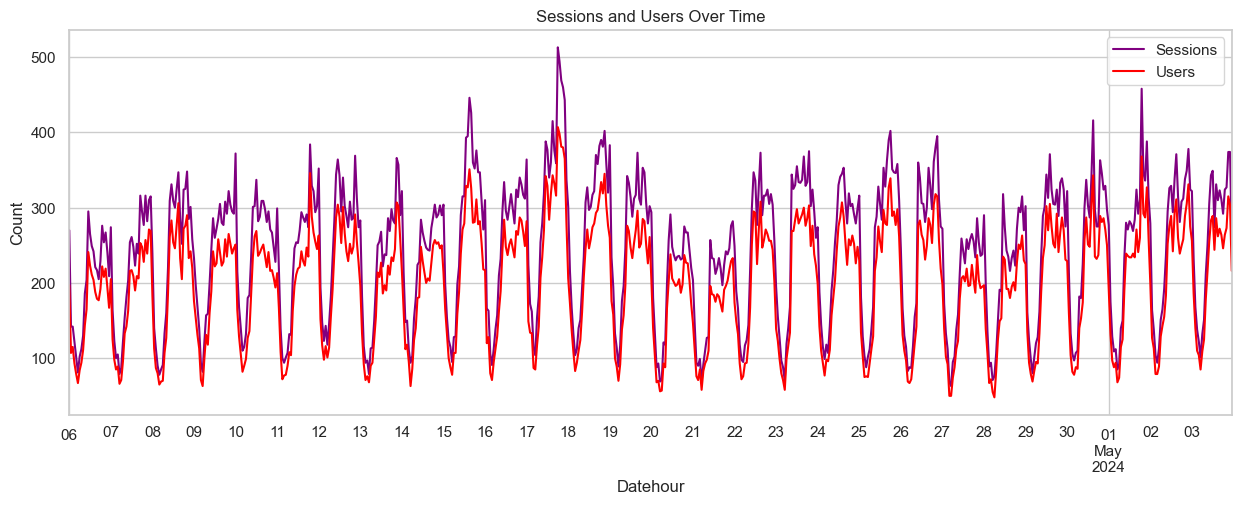

In [25]:
sns.set(style="whitegrid")
plt.figure(figsize=(15,5))
df.groupby("Datehour")[["Sessions","Users"]].sum().plot(ax=plt.gca(), color=["purple","red"])
plt.xlabel("Datehour")
plt.ylabel("Count")
plt.title("Sessions and Users Over Time")
plt.legend(["Sessions","Users"])
plt.show()

In [ ]:
# We conclude that the website receives the highest number of users between 15:00 and 20:00,
# meaning that the sessions during this time period are the most active.

# Users By Market Channel

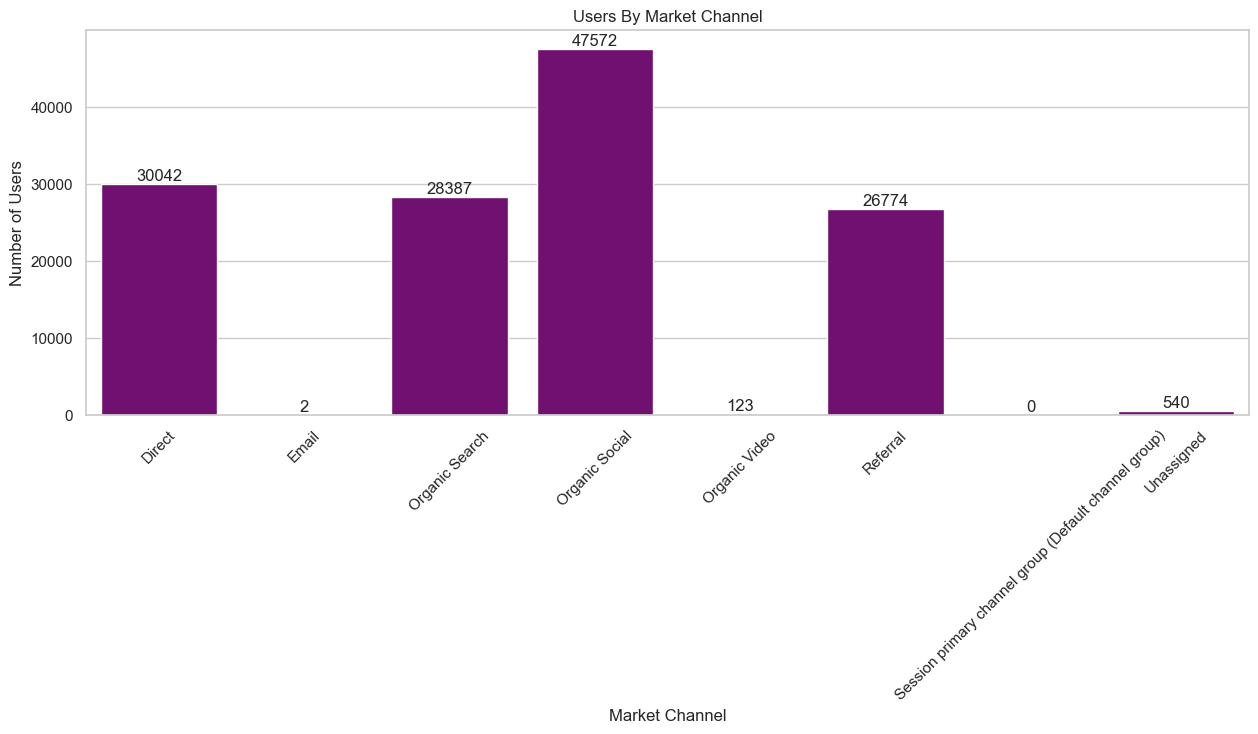

In [26]:

channel_data = df.groupby("channel group")["Users"].sum().reset_index()
plt.figure(figsize=(15,5))
ax = sns.barplot(x="channel group", y="Users", data=channel_data ,  color="purple")
ax.bar_label(ax.containers[0])
plt.title("Users By Market Channel")
plt.xticks(rotation = 45)
plt.xlabel("Market Channel")
plt.ylabel("Number of Users")
plt.show()

In [ ]:
# Organic Social is the most effective channel for driving user traffic.
# - Email, Organic Search and Organic Video are currently not effective.
# - Direct and Referral channels have potential to improve

# Engagement Distribution by Channel

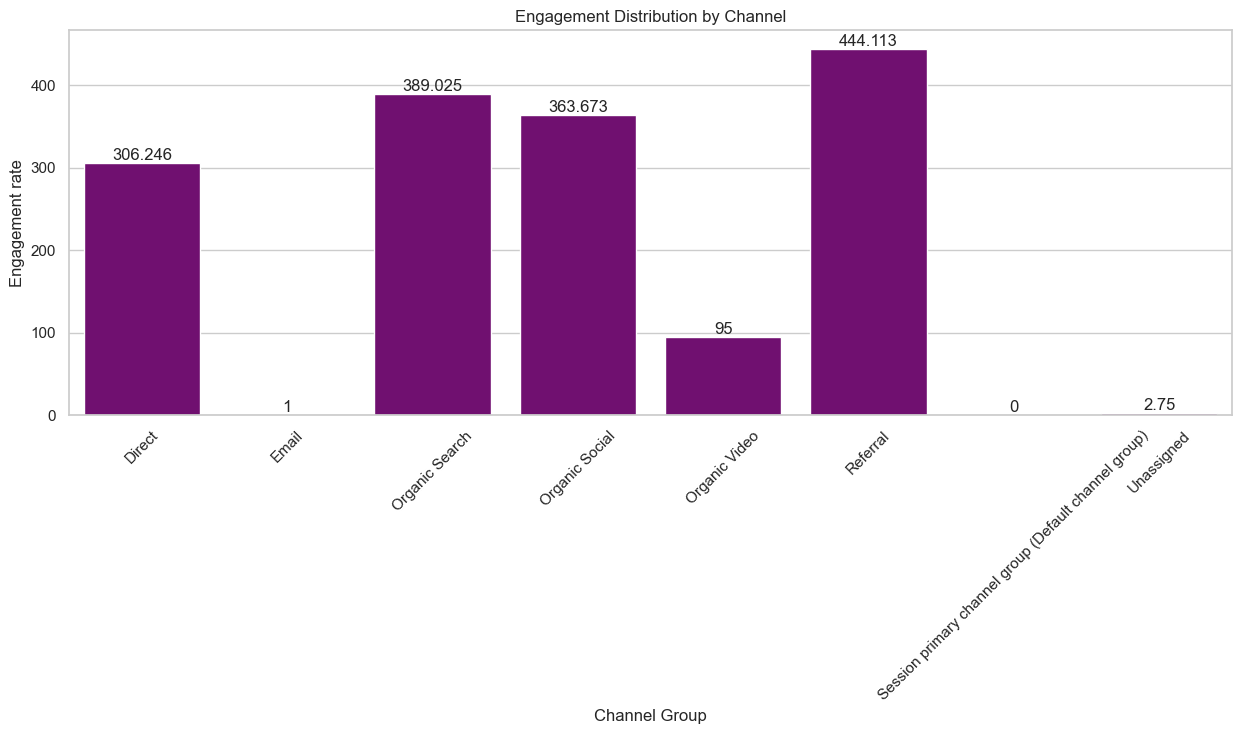

In [32]:

plt.figure(figsize = (15 , 5))
channel_engagement = df.groupby("channel group")["Engagement rate"].sum().reset_index()
ax=sns.barplot(x = "channel group" , data = channel_engagement , y = "Engagement rate" , color  = "purple")
ax.bar_label(ax.containers[0])
plt.title("Engagement Distribution by Channel")
plt.xlabel("Channel Group")
plt.ylabel("Engagement rate")
plt.xticks(rotation = 45)
plt.show()


In [ ]:
# We conclude that Referral channels have the highest engagement distribution.
# Channels like Organic Social, Organic Search, and Direct show moderate engagement and need improvement.
# Channels like Email, Unassigned, and Organic Video have very low engagement and require strategic attention.

# Engaged Vs Non Engaged Session

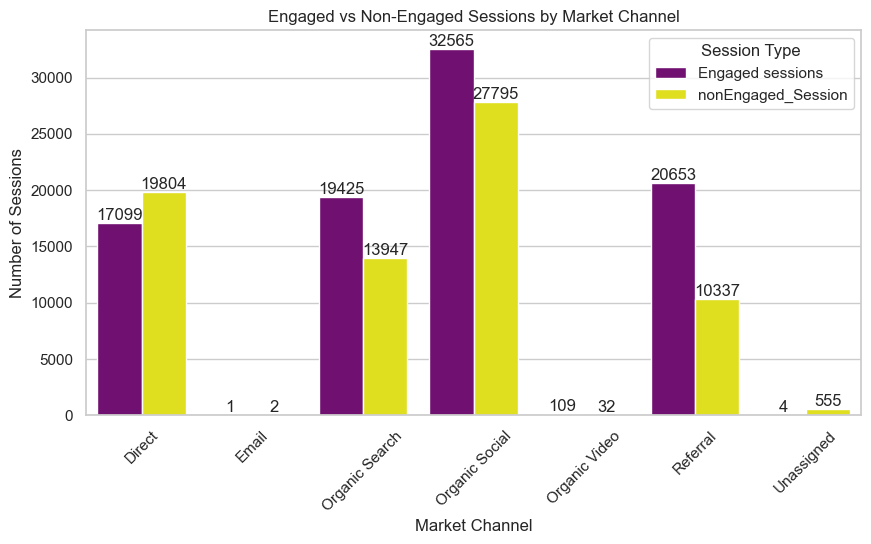

In [77]:
plt.figure(figsize=(10,5))
sessions_df = df.groupby("channel group")[["Sessions","Engaged sessions"]].sum().reset_index()
sessions_df["nonEngaged_Session"] = sessions_df["Sessions"] - sessions_df["Engaged sessions"]
sessions_df_melted = sessions_df.melt(
    id_vars="channel group",
    value_vars=["Engaged sessions","nonEngaged_Session"],
    var_name="Session Type",
    value_name="Count"
)
ax = sns.barplot(
    x="channel group",
    y="Count",
    hue="Session Type",
    data=sessions_df_melted,
    palette=["purple","yellow"]
)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Engaged vs Non-Engaged Sessions by Market Channel")
plt.xlabel("Market Channel")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Organic Social generates the highest traffic and engagement, while Direct traffic has more non-engaged sessions. Referral
# traffic shows strong engagement, whereas Email and Organic Video contribute very little traffic.

# User Traffic by hour and  Channel

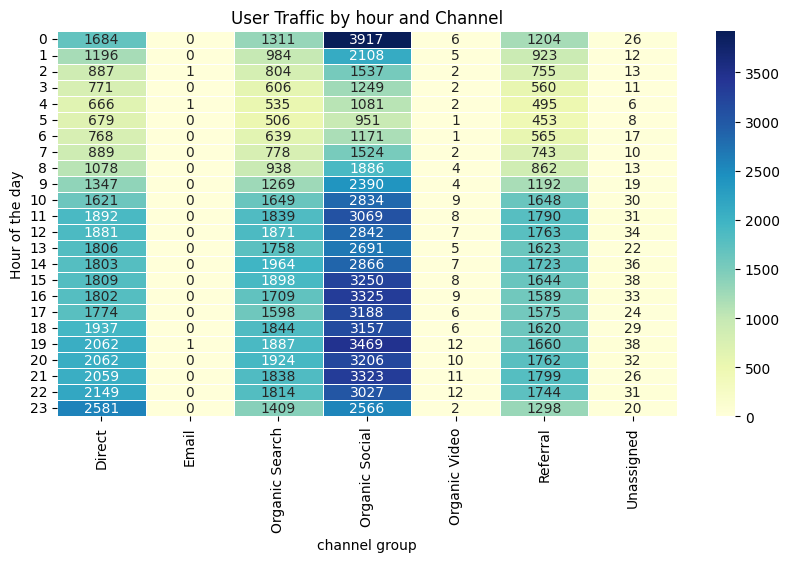

In [33]:
plt.figure(figsize=(10,5))
traffic_hour = df.groupby([ "Hour", "channel group" ])["Sessions"].sum().unstack().fillna(0)
plt.title("User Traffic by hour and Channel")
sns.heatmap( traffic_hour  , cmap = 'YlGnBu' ,   linewidths= .7 ,  annot = True ,  fmt = '.0f')
plt.xlabel("channel group")
plt.ylabel("Hour of the day")
plt.show()

In [ ]:
# We Conclude that The highest traffic comes from Organic Social, with the peak occurring at 12 AM (Hour 0)

# Engagement Rate vs Session Over time

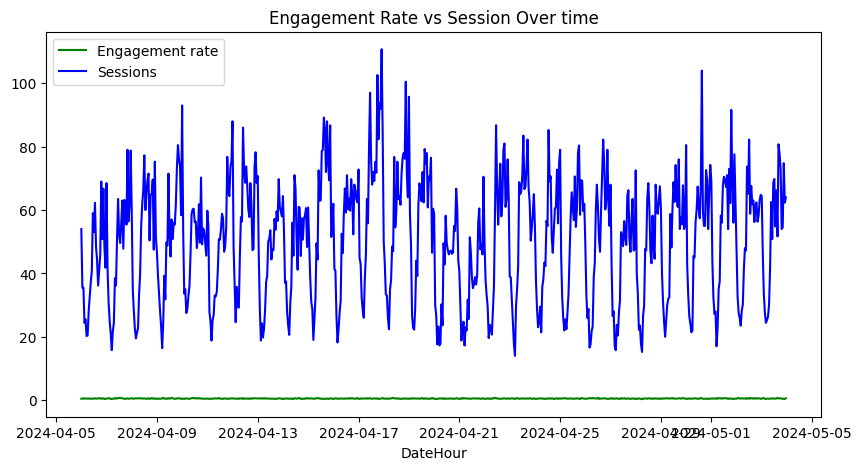

In [36]:
df_plot = df.groupby("Datehour")[["Engagement rate","Sessions"]].mean().reset_index()
plt.figure(figsize=(10,5))
plt.plot(df_plot["Datehour"], df_plot["Engagement rate"], label="Engagement rate", color="green")
plt.plot(df_plot["Datehour"], df_plot["Sessions"], label="Sessions", color="blue")
plt.title("Engagement Rate vs Session Over time")
plt.xlabel("DateHour")

plt.legend()
plt.show()

In [ ]:
# We conclude that the number of sessions is high, but the engagement rate is very low